# Exploratory Data Analysis

This notebook explores the UCI Default of Credit Card Clients dataset before preprocessing and feature engineering.

**Objective:** understand dataset structure, target distribution, feature distributions, historical repayment/payment behavior, relationships with default, and initial data-quality implications.

No preprocessing or feature engineering is performed in this notebook.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
SRC = ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from propensity_prediction.data.load import load_raw_data

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

## 1. Load the raw dataset


In [2]:
df = load_raw_data()
df.head()

,Unnamed: 0_level_0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print("Shape:", df.shape)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))


Shape: (30000, 25)
Number of rows: 30000
Number of columns: 25


The raw loader preserves the source spreadsheet's two-level column structure. The first spreadsheet column is an identifier column represented as `ID` under the source's unnamed first-level header.

## 2. Schema and data types


In [4]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": [df[col].nunique(dropna=False) for col in df.columns],
})
schema

,,dtype,missing,unique_values
Unnamed: 0_level_0,ID,int64,0,30000
X1,LIMIT_BAL,int64,0,81
X2,SEX,int64,0,2
X3,EDUCATION,int64,0,7
X4,MARRIAGE,int64,0,4
X5,AGE,int64,0,56
X6,PAY_0,int64,0,11
X7,PAY_2,int64,0,11
X8,PAY_3,int64,0,11
X9,PAY_4,int64,0,11


In [5]:
print("Total missing values:", df.isna().sum().sum())
print("Duplicate complete rows:", df.duplicated().sum())

Total missing values: 0
Duplicate complete rows: 0


## 3. Target distribution


In [6]:
target_col = ("Y", "default payment next month")
target_counts = df[target_col].value_counts().sort_index()
target_proportions = df[target_col].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_proportions
})
target_summary

,count,proportion
"(Y, default payment next month)",,
0,23364,0.7788
1,6636,0.2212


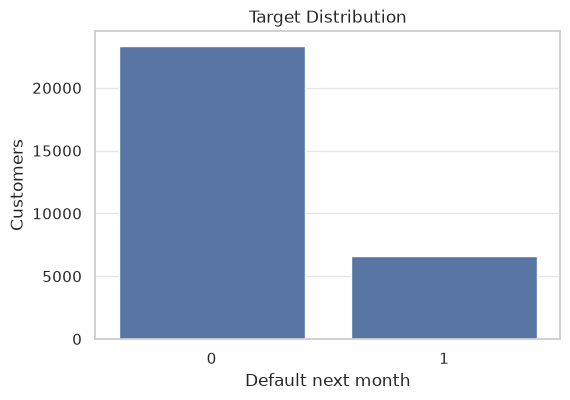

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Target Distribution")
plt.xlabel("Default next month")
plt.ylabel("Customers")
plt.show()

The target is binary. The observed distribution should be considered when selecting evaluation metrics and interpreting model performance; accuracy alone may hide differences between the two classes.

## 4. Customer demographics and credit exposure


In [8]:
id_col = ("Unnamed: 0_level_0", "ID")
numeric_cols = [
    ("X1", "LIMIT_BAL"),
    ("X5", "AGE"),
]
df[numeric_cols].describe().T

,,count,mean,std,min,25%,50%,75%,max
X1,LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.0,140000.0,240000.0,1000000.0
X5,AGE,30000.0,35.485500,9.217904,21.0,28.0,34.0,41.0,79.0


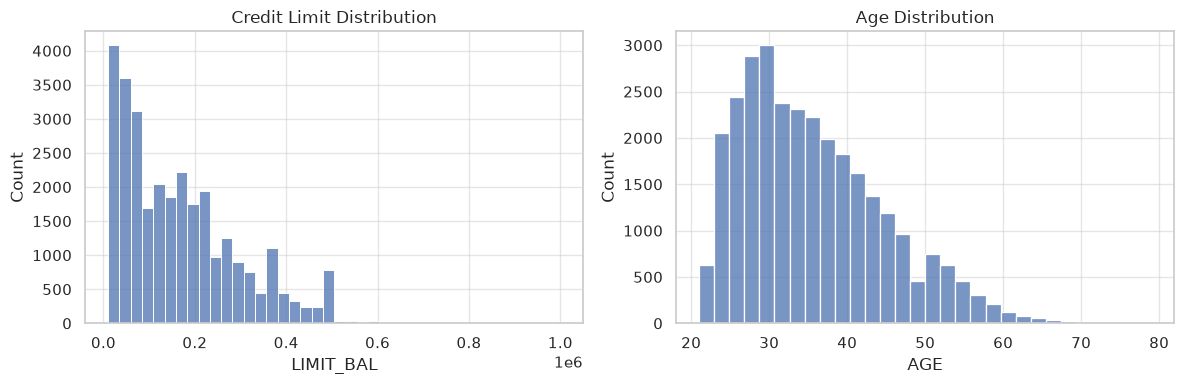

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[("X1", "LIMIT_BAL")], bins=40, ax=axes[0])
axes[0].set_title("Credit Limit Distribution")
axes[0].set_xlabel("LIMIT_BAL")

sns.histplot(df[("X5", "AGE")], bins=30, ax=axes[1])
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("AGE")

plt.tight_layout()
plt.show()

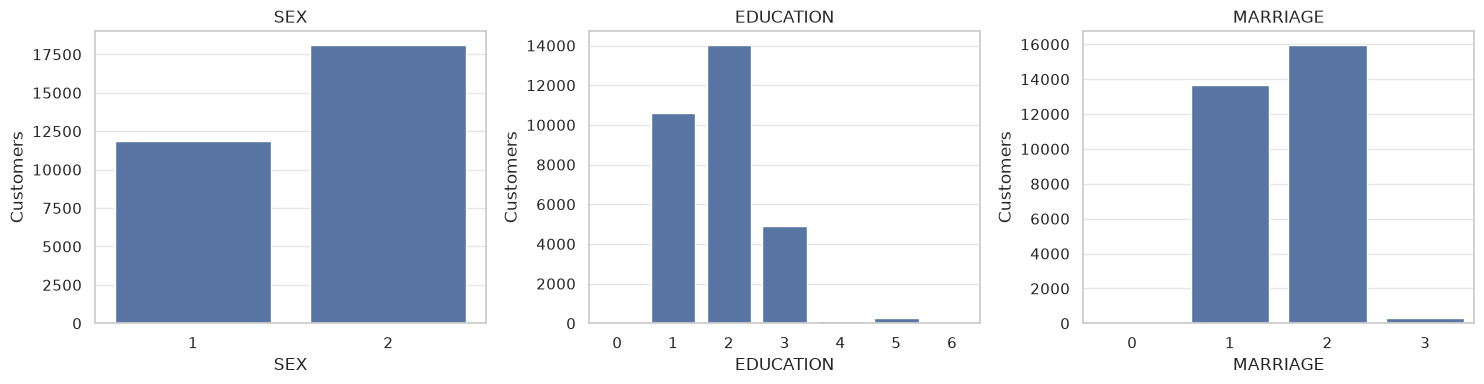

In [10]:
categorical_cols = [
    ("X2", "SEX"),
    ("X3", "EDUCATION"),
    ("X4", "MARRIAGE"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col[1])
    ax.set_xlabel(col[1])
    ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

The categorical variables are encoded as integers. Their numeric representation should not automatically be interpreted as continuous magnitude.

## 5. Repayment-status history


In [11]:
pay_status_cols = [
    ("X6", "PAY_0"),
    ("X7", "PAY_2"),
    ("X8", "PAY_3"),
    ("X9", "PAY_4"),
    ("X10", "PAY_5"),
    ("X11", "PAY_6"),
]

pay_status_summary = pd.DataFrame({
    col[1]: df[col].value_counts().sort_index() for col in pay_status_cols
}).fillna(0).astype(int)
pay_status_summary

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


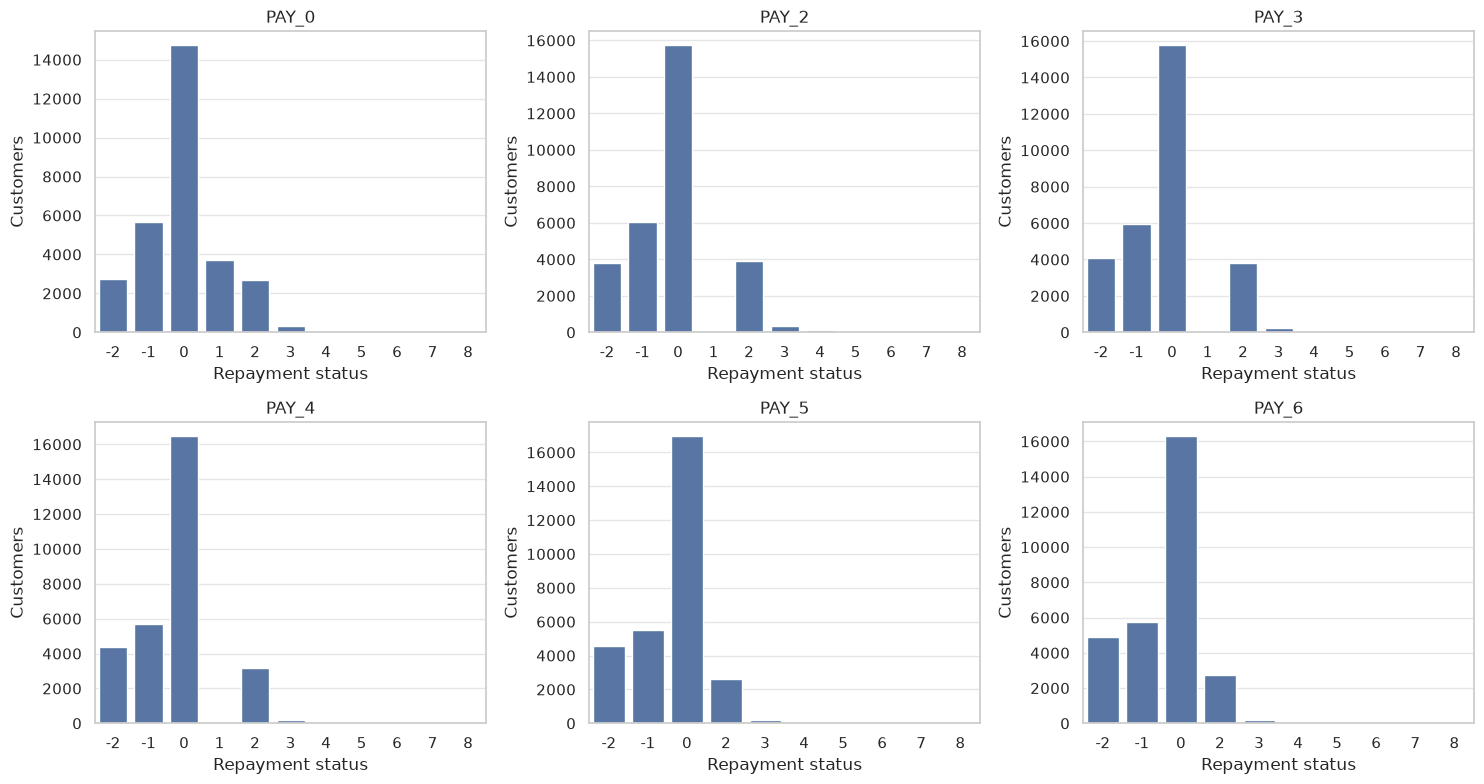

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, pay_status_cols):
    sns.countplot(data=df, x=col, ax=ax, order=sorted(df[col].unique()))
    ax.set_title(col[1])
    ax.set_xlabel("Repayment status")
    ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

Repayment-status variables provide six months of historical repayment behavior. Their category encoding and the observed category frequencies will inform later preprocessing decisions.

## 6. Billing and payment history


In [13]:
bill_cols = [
    ("X12", "BILL_AMT1"), ("X13", "BILL_AMT2"), ("X14", "BILL_AMT3"),
    ("X15", "BILL_AMT4"), ("X16", "BILL_AMT5"), ("X17", "BILL_AMT6")
]
payment_cols = [
    ("X18", "PAY_AMT1"), ("X19", "PAY_AMT2"), ("X20", "PAY_AMT3"),
    ("X21", "PAY_AMT4"), ("X22", "PAY_AMT5"), ("X23", "PAY_AMT6")
]

history_summary = pd.DataFrame({
    col[1]: df[col].describe() for col in bill_cols + payment_cols
}).T
history_summary

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
PAY_AMT3,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
PAY_AMT4,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0


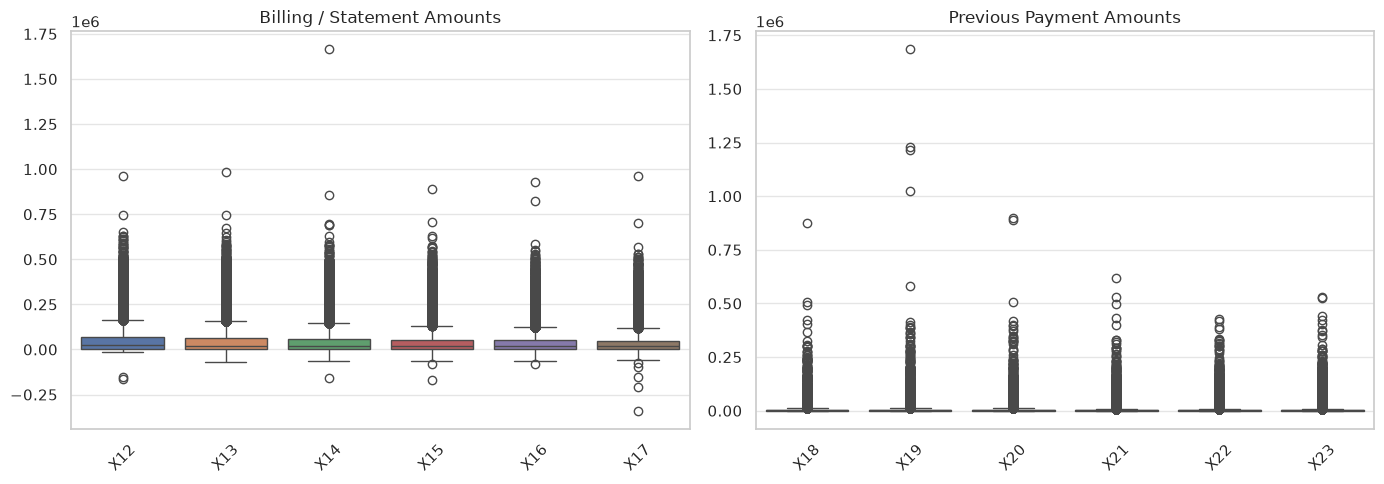

In [14]:
bill_months = ["Sep", "Aug", "Jul", "Jun", "May", "Apr"]
payment_months = ["Sep", "Aug", "Jul", "Jun", "May", "Apr"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[[col for col in bill_cols]], ax=axes[0])
axes[0].set_title("Billing / Statement Amounts")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df[[col for col in payment_cols]], ax=axes[1])
axes[1].set_title("Previous Payment Amounts")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The billing and payment variables can have substantially different scales and distributions. This will matter for later modeling and preprocessing.

## 7. Feature relationships with default


In [15]:
target_by_feature = {}

for col in numeric_cols + categorical_cols:
    target_by_feature[col[1]] = df[target_col].groupby(df[col]).mean()

target_by_feature

{'LIMIT_BAL': (X1, LIMIT_BAL)
 10000      0.399594
 16000      0.000000
 20000      0.353239
 30000      0.352795
 40000      0.400000
              ...   
 750000     0.000000
 760000     0.000000
 780000     0.000000
 800000     0.000000
 1000000    0.000000
 Name: (Y, default payment next month), Length: 81, dtype: float64,
 'AGE': (X5, AGE)
 21    0.208955
 22    0.301786
 23    0.265306
 24    0.266193
 25    0.254637
 26    0.201433
 27    0.211916
 28    0.202981
 29    0.195016
 30    0.196416
 31    0.188168
 32    0.194301
 33    0.187609
 34    0.198795
 35    0.203055
 36    0.229242
 37    0.219981
 38    0.205508
 39    0.208595
 40    0.214943
 41    0.224515
 42    0.232997
 43    0.223881
 44    0.231429
 45    0.188006
 46    0.275439
 47    0.239521
 48    0.223176
 49    0.263274
 50    0.245742
 51    0.258824
 52    0.256579
 53    0.227692
 54    0.226721
 55    0.272727
 56    0.275281
 57    0.221311
 58    0.254098
 59    0.253012
 60    0.343284
 61    0.3750

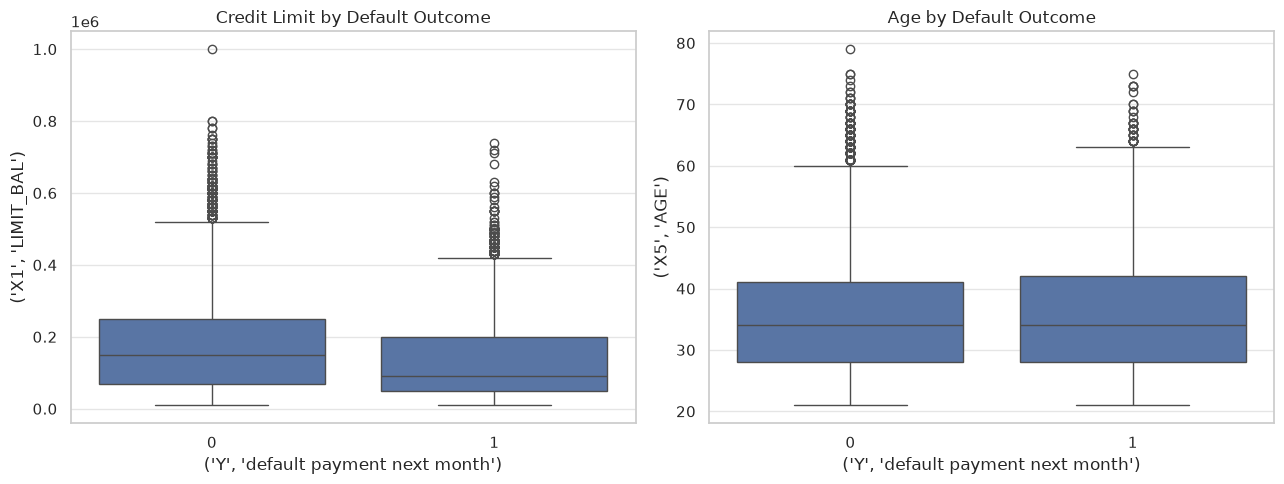

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x=target_col, y=("X1", "LIMIT_BAL"), ax=axes[0])
axes[0].set_title("Credit Limit by Default Outcome")

sns.boxplot(data=df, x=target_col, y=("X5", "AGE"), ax=axes[1])
axes[1].set_title("Age by Default Outcome")

plt.tight_layout()
plt.show()

In [17]:
repayment_default_rates = pd.DataFrame({
    col[1]: df[target_col].groupby(df[col]).mean()
    for col in pay_status_cols
}).T

repayment_default_rates

,-2,-1,0,1,2,3,4,5,6,7,8
PAY_0,0.132294,0.167781,0.128113,0.339479,0.691414,0.757764,0.684211,0.500000,0.545455,0.777778,0.578947
PAY_2,0.182708,0.159669,0.159123,0.178571,0.556150,0.616564,0.505051,0.600000,0.750000,0.600000,0.000000
PAY_3,0.185312,0.155945,0.174512,0.250000,0.515580,0.575000,0.578947,0.571429,0.608696,0.814815,0.666667
PAY_4,0.192502,0.158959,0.183288,0.500000,0.523267,0.611111,0.666667,0.514286,0.400000,0.827586,0.500000
PAY_5,0.196876,0.161943,0.188529,NaN,0.541889,0.634831,0.607143,0.588235,0.750000,0.827586,1.000000
PAY_6,0.200409,0.169861,0.188444,NaN,0.506508,0.641304,0.632653,0.538462,0.736842,0.826087,1.000000


These comparisons are descriptive associations only. They do not establish that changing a feature would cause default risk to change.

## 8. Correlation analysis


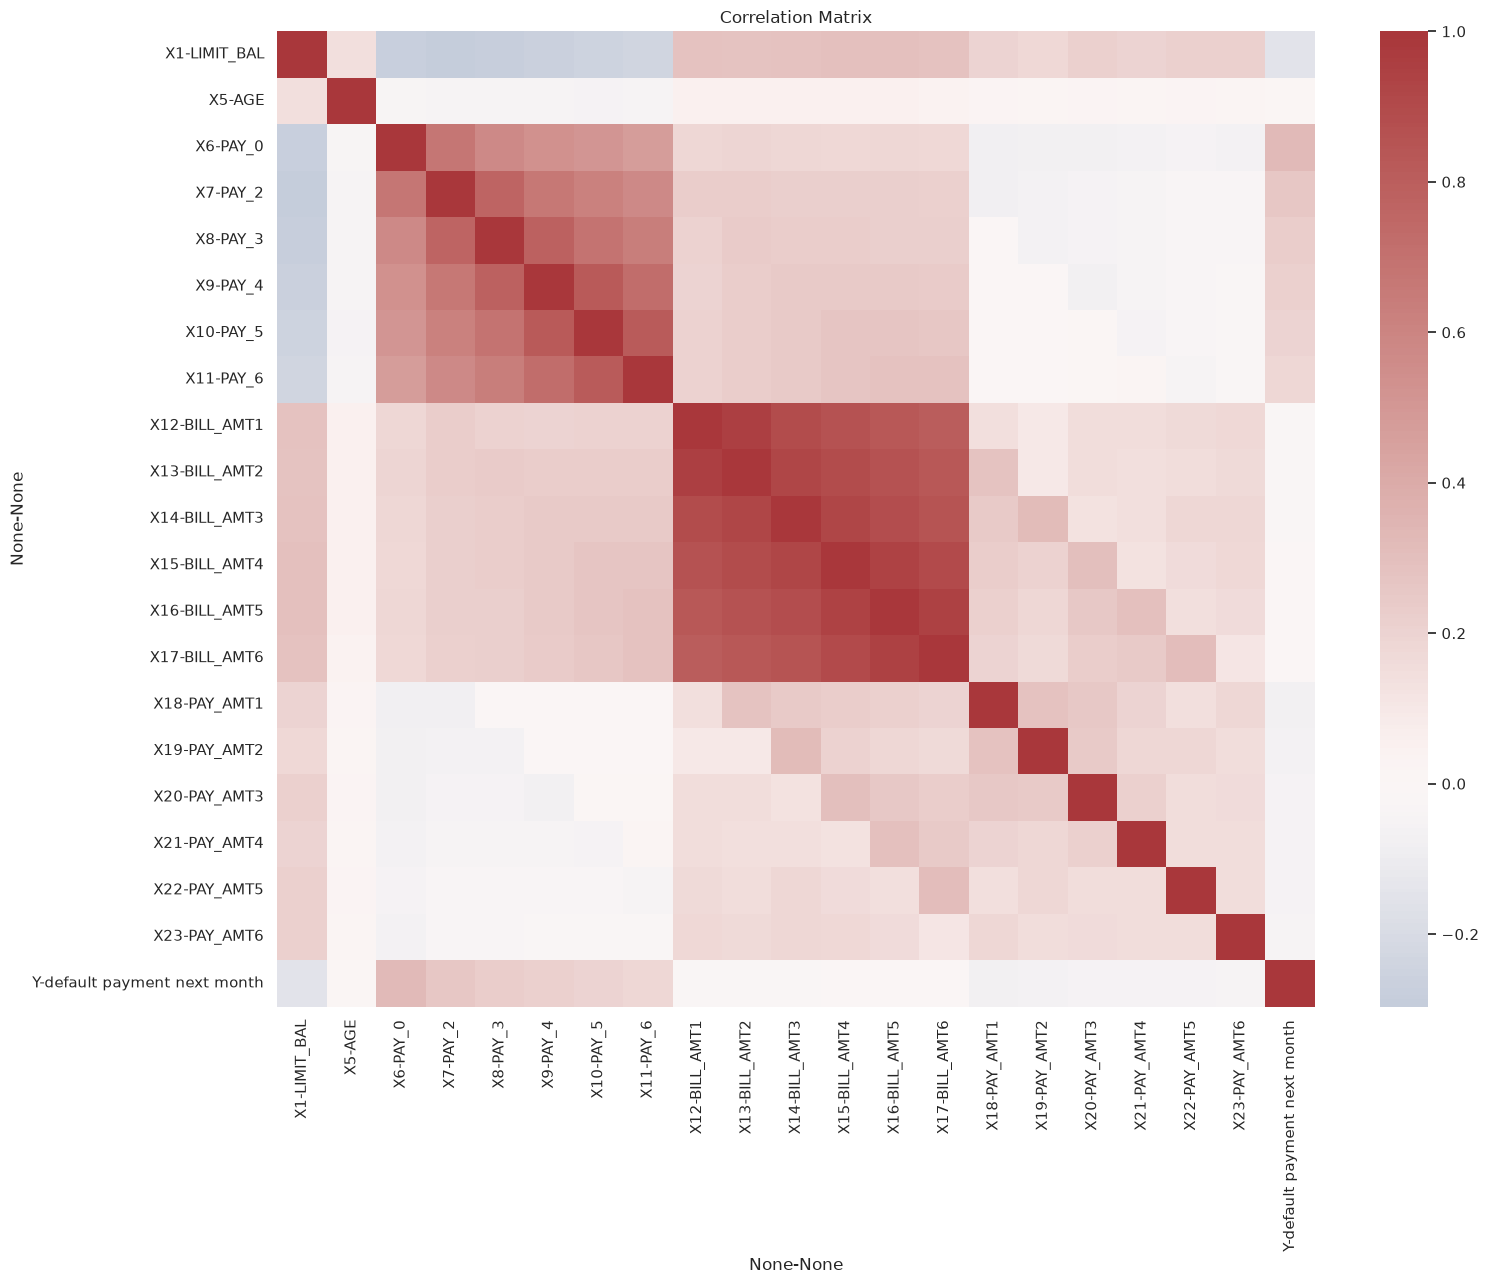

In [18]:
correlation_cols = numeric_cols + pay_status_cols + bill_cols + payment_cols + [target_col]
corr = df[correlation_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr, center=0, cmap="vlag", square=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Correlation is useful for identifying broad relationships and potentially redundant variables, but it is not sufficient by itself for feature selection or causal interpretation.

## 9. Initial EDA observations


In [19]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Default rate:", df[target_col].mean())
print("Age range:", df[("X5", "AGE")].min(), "to", df[("X5", "AGE")].max())
print("Education values:", sorted(df[("X3", "EDUCATION")].unique()))
print("Marriage values:", sorted(df[("X4", "MARRIAGE")].unique()))

Dataset shape: (30000, 25)
Missing values: 0
Duplicate rows: 0
Default rate: 0.2212
Age range: 21 to 79
Education values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Marriage values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### Findings to carry into preprocessing

- The dataset contains 30,000 customer observations.
- The loaded raw representation contains 25 columns because the source spreadsheet includes an additional identifier column alongside the 24 semantic variables.
- There are no missing values or duplicate complete rows in the validated raw dataset.
- The target is binary and imbalanced, so model evaluation should include metrics beyond accuracy.
- Demographic variables are categorical despite integer encoding.
- Repayment-status variables contain ordered behavioral information whose encoding should be examined before deciding how to transform them.
- Billing and payment variables have different scales and distributions.
- `EDUCATION` contains observed values outside the documented 1–4 categories, and `MARRIAGE` contains an observed `0`; these remain data-quality findings rather than automatic corrections.
- Associations observed during EDA should not be interpreted as causal effects.

No cleaning, imputation, encoding, scaling, outlier treatment, or feature engineering is performed here.